# Fast Example: FRET histograms and Multi-Spot data

> **Note**
>
> If you have a $\mu s$ALEX or PIE/$ns$ALEX setup, the [E/S Analysis](ESplotTutorial.ipynb)
> will probably be more informative.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import smfbursts as smf
import smfbursts.datamodel.multifit as smfit

## Load Data

First we import that data from a file containing smFRET data.

In [2]:
raw = smf.photonHDF5.load('data/12d_New_30p_320mW_steer_3.hdf5')

# correct problem in file, only 1 of the 2 detection channels was defined
raw.setup['detection_wavelengths'] = np.array([580e-9, 680e-9])

data = smf.photonHDF5.regularize_dets(raw)

## Using `smf.fretfactory`

First the burst search parameters need to be defined.

This is done first by defining how to assess background, and then defining the size of burst search.

Typically a basic gate is also defined. 
See [Burst Tutorial](BurstsTutorial.ipynb) for example of a detailed analysis.
See [Burst Search Explanation](BurstSearchTutorial.ipynb) to understand the ins-and-outs of burst search.

The `smf.fretfactory` provides a lot of easy constructor functions to reduce lines of code.
In this first section of the tutorial, we will use it to build our burst search.

In [3]:
dbg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, auto_threshold=True, tail_min=5e-4, F_bg=2.0)
dbs = smf.fretfactory.make_burst_search(bg=dbg['bg'], m=10, F=6.0, streams=smf.PhSel('all'))
gate = smf.make_geq_gate(dbs['NphAll_bg'], 50.0)

Plot the Proximity Ratio ($^{ii}E_{app}$) histogram.

Note the use of the default object to get some easy default kwargs:

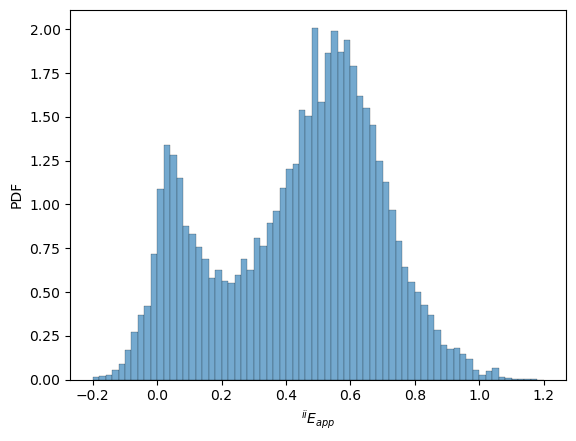

In [4]:
smf.plot.hist_bar(data, dbs['E_bg'], bins=smf.fretfactory.MonoExdefaults['ratio_bins'], 
                  normalize='pdf', **smf.fretfactory.MonoExdefaults['histbar']);

Fitting with 2 gaussian distributions:

See the [multi fit tutorial](MultiFitTutorial.ipynb) for a detailed description of how
the multi-distribution functions behave.

First we setup an initial fitting array with the `smfit.make_init` function,
passing `func=smfit.ndgaus_cdf` to indicate we are fitting with a 

In [5]:
# Step 1: Define initial guess and bounds (pre-fit)
prinit = smfit.make_init(func=smfit.ngaus_cdf, 
                         sigma=[0.05, 0.1], # guess standard deviations
                         mu=[0.1, 0.6], # guess locations
                         amps=[0.2, 0.8]) # guess amplitude contributions
prbounds = smfit.make_bounds(func=smfit.ngaus_cdf, 
                             sigma=[[1e-4, 0.5], # bounds for standard deviation
                                    [1e-4, 0.5]], # most imporant is > 0 to prevent error
                             mu=[[-0.05, 0.3], # range for first Gaussian, modify based on distribution
                                 [0.3, 0.8]] # range for second Gaussian, modify based on distribution
                            )

# Step 2: Generate Histogram
prhist = smfit.Hist.from_columns(data, dbs['E_bg'], gate=gate, 
                                 bins=smf.fretfactory.MonoExdefaults['ratio_bins'])
# Step 3: perform fit
prfit = smfit.fit_hist_cdf(prhist, smfit.ngaus_cdf, prinit, bounds=prbounds, 
                           method='Nelder-Mead')
# Get human-readable output
smfit.unwrap_param(smfit.ngaus_cdf, prfit.x)

{'mu': array([0.04303209, 0.55580336]),
 'sigma': array([0.0375688 , 0.10194459]),
 'amps': array([0.28356944, 0.71643056])}

Plot fit:

{'mu': array([0.04303209, 0.55580336]),
 'sigma': array([0.0375688 , 0.10194459]),
 'amps': array([0.28356944, 0.71643056])}

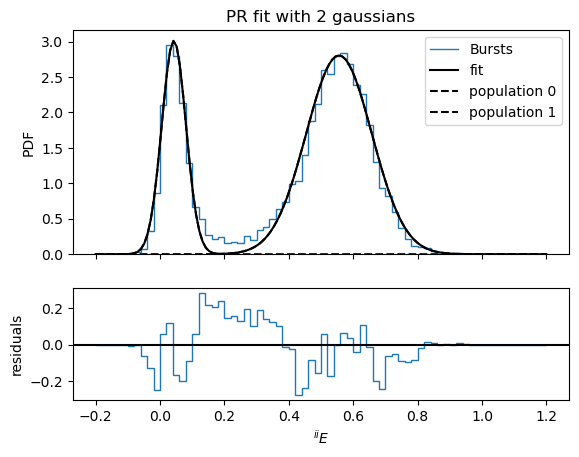

In [6]:
# plot with residuals
fig, ax = plt.subplots(2,1, height_ratios=[2,1], sharex=True)
ax[0].stairs(prhist.pdf, prhist.bins[0], label='Bursts')
smf.plot.plot_multi_dist(smfit.ngaus_pdf, prfit.x, np.linspace(-0.2,1.2,140), 
                         dist_kwargs={'c':'k', 'label':'fit'}, 
                         subdist_kwargs=[{'ls':'--','c':'k','label':f'population {i}'} 
                                         for i in range(2)], ax=ax[0], label='Bursts')
ax[0].set_title(r"PR fit with 2 gaussians")
ax[0].set_ylabel('PDF')
ax[0].legend()
resid = prhist.pdf - smfit.ngaus_pdf(prfit.x, prhist.bincenters[0])
ax[1].stairs(resid, prhist.bins[0])
ax[1].axhline(0, c='k')
ax[1].set_ylabel("residuals")
ax[1].set_xlabel("$^{ii}E$")

smfit.unwrap_param(smfit.ngaus_cdf, prfit.x)

## Defining Params from base parts:

The use of `smf.fretfactory` functions makes things faster and easier,
but also means that certain things are taken care of "under the hood".
Additionally, more `Param` and `Column` objects are created than strictly necessary.

So below is a version of the code that creates the same histograms, but with directly created `Param` and `Column` objects instead.

In [7]:
# define background parameters
prd = smf.Param(smf.Periods, params={'period':60.0, 'start_at':'time_min', 'stop_at':'over', 'detdef':data.detdef})
bg = smf.Param(smf.BG, params={'func':smf.bg.exp_mlefit, 'auto_threshold':True, 'tail_min':5e-4, 'F_bg':1.7}, parents={'base':prd})
##################################################################
# Note :                                                         #
# Best practice is to check that the background fit is good, and #
# the background rates are reasonable to ensure the data is of   #
# sufficient quality to proceed with burst analysis              #
##################################################################

# define burst search parameters
brst = smf.Param(smf.Bursts, params={'m':10, 'F':6.0}, parents={'bg':bg})
nphbg = smf.Param(smf.NphBG, params={'single':True}, parents={'base':brst, 'bg':bg})
nph_bg = smf.Column(nphbg, 'nph_bg', smf.PhSel('all'))

# define default gate and 
gate = smf.make_geq_gate(nph_bg, 50)
bursts = brst.regate(gate)
numphbg = nphbg.regate(gate)
PR = smf.Column(numphbg, 'E_bg', title='PR')

Now to plot a simple FRET histogram we would

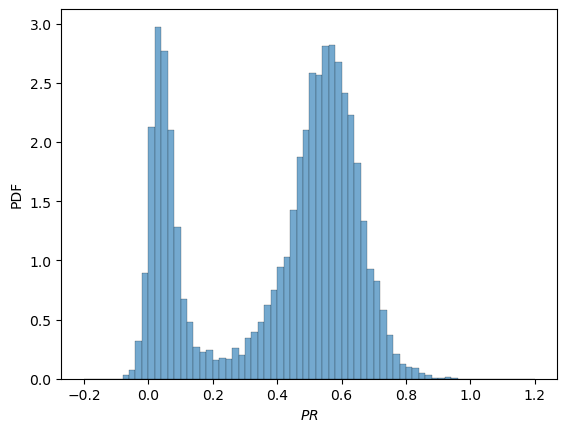

In [8]:
smf.plot.hist_bar(data, PR, bins=smf.fretfactory.MonoExdefaults['ratio_bins'], 
                  normalize='pdf', **smf.fretfactory.MonoExdefaults['histbar']);

And fitting to a 2 guassian distribution

In [9]:
# Step 1: Define initial guess and bounds (pre-fit)
prinit = smfit.make_init(func=smfit.ngaus_cdf, 
                         sigma=[0.05, 0.1], # guess standard deviations
                         mu=[0.1, 0.6], # guess locations
                         amps=[0.2, 0.8]) # guess amplitude contributions
prbounds = smfit.make_bounds(func=smfit.ngaus_cdf, 
                             sigma=[[1e-4, 0.5], # bounds for standard deviation
                                    [1e-4, 0.5]], # most imporant is > 0 to prevent error
                             mu=[[-0.05, 0.3], # range for first Gaussian, modify based on distribution
                                 [0.3, 0.8]] # range for second Gaussian, modify based on distribution
                            )

# Step 2: Generate Histogram
prhist = smfit.Hist.from_columns(data, PR, gate=gate, 
                                 bins=smf.fretfactory.MonoExdefaults['ratio_bins'])
# Step 3: perform fit
prfit = smfit.fit_hist_cdf(prhist, smfit.ngaus_cdf, prinit, bounds=prbounds, 
                           method='Nelder-Mead')
# Get human-readable output
smfit.unwrap_param(smfit.ngaus_cdf, prfit.x)

{'mu': array([0.04258967, 0.55595695]),
 'sigma': array([0.0376849 , 0.10177333]),
 'amps': array([0.28403171, 0.71596829])}

In [10]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
